In [ ]:
import numpy as np 
from scipy.special import logsumexp

class PHMM_forward: 
    """
    A Pair Hidden Markov Model (PHMM) for aligning two sequences
    """
    def __init__(self, states, end_state):
        """
        Initializes the PHMM model 

        Args:
            states (list): A list of all possible states
            end_state (State): End state used to indicate the termination of the sequence 
        """
        self.states = states
        self.end_state = end_state
        
    
    ############## DIT AANGEPAST VOOR GENORMALISEERDE MATCH EMISSIES ################
    def compute_normalized_match_emissions(self):
        match_state = next((s for s in self.states if s.name == "M"), None)
        if not match_state:
            raise ValueError("Match state (M) not found")

        E = np.zeros((self.num_AIS, self.num_RF))  # inclusief index 0 (dummy)
        
        for i in range(1, self.num_AIS):   # let op: indexverschuiving
            for j in range(1, self.num_RF):
                obs = (self.AIS_seq[i - 1], self.RF_seq[j - 1])
                E[i, j] = match_state.emission(obs)
        
        # normaliseren per kolom j
        column_sums = E.sum(axis=0, keepdims=True) + 1e-300
        E = E / column_sums  # Broadcasting normalisatie

        return E
    
    ####################################################################################
        
    def forward(self, AIS_seq, RF_seq):
        """
        Executes the Forward algorithm 

        Args:
            AIS_seq (list[tuple[datetime, tuple[float, float]]]): List of AIS observations 
            RF_seq (list[tuple[datetime, tuple[float, float]]]): List of RF observations 

        Returns:
            The probability of a sequence summed over all possible paths 
        """

        self.AIS_seq = AIS_seq
        self.RF_seq = RF_seq
        self.num_AIS = len(AIS_seq) + 1
        self.num_RF = len(RF_seq) + 1
        self.num_states = len(self.states)
                
        self.γ = np.full((self.num_states, self.num_AIS, self.num_RF), -np.inf)
            
        ############## DIT AANGEPAST VOOR GENORMALISEERDE MATCH EMISSIES ################
        self.match_emission_matrix = self.compute_normalized_match_emissions()
        ########################################################

        self._induction()
        return self._final_probability()
    
    def is_valid_match(self, i, j):
        ais_point = self.AIS_seq[i - 1]
        rf_point = self.RF_seq[j - 1]

        max_dist_km = 2  # voorbeeld
        max_time_sec = 120  # voorbeeld

        dist = haversine(ais_point[1], rf_point[1])
        time_diff = abs((ais_point[0] - rf_point[0]).total_seconds())

        return dist < max_dist_km and time_diff < max_time_sec
    
    def _induction(self):
        """
        Performs the forward pass of the Forward algorithm, 
        calculating the probability of being in each state at each position by adding up the probabilities of all possible paths that could get there
        """
        for state in self.states:
            self.γ[state.id, 0, 0] = 0.0 if state.name == "begin" else  -np.inf
            
        for i in range(self.num_AIS):
            for j in range(self.num_RF):
                if i == 0 and j == 0:
                    continue
                
                for curr_state in self.states:
                    Δ_i, Δ_j = curr_state.Δ()
                    prev_i, prev_j = i - Δ_i, j - Δ_j
                    
                    if prev_i < 0 or prev_j < 0:
                        continue
                    
                    if curr_state.name == "M" and not self.is_valid_match(i, j):
                        self.γ[curr_state.id, i, j] = -np.inf
                        continue  # skip this state entirely at this position
                
                    observation = (self.AIS_seq[prev_i] if Δ_i else None, self.RF_seq[prev_j] if Δ_j else None)
                    
                    log_probs = []
                    
                    for prev_state in self.states:
                        if prev_state.name in curr_state.get_predecessors(prev_i, prev_j):
                            prev_log_prob = self.γ[prev_state.id, prev_i, prev_j]
                            
                            trans_prob = curr_state.transition(prev_state.name, prev_i, prev_j, self.AIS_seq, self.RF_seq)
                            log_trans_prob = np.log(trans_prob + 1e-300)
                            
                            if curr_state.name == "M":
                                print(trans_prob, log_trans_prob, prev_state.name, prev_i, prev_j)

                            #########################################
                            if curr_state.name == "M":
                                emiss_prob = self.match_emission_matrix[i, j]
                            else:
                                emiss_prob = curr_state.emission(observation)
                            #######################################

                            log_emiss_prob = np.log(emiss_prob + 1e-300)
                            
                            prob = prev_log_prob + log_trans_prob + log_emiss_prob
                            
                            log_probs.append(prob)
                    
                    if log_probs:
                        self.γ[curr_state.id, i, j] = logsumexp(log_probs)
                                            
    def _final_probability(self):
        """
        Calculates the total probability 
        """
        end_i = len(self.AIS_seq)
        end_j = len(self.RF_seq)
        
        log_probs = []
        
        for prev_state in self.states:
            if prev_state.name in self.end_state.get_predecessors(end_i, end_j):
                trans_prob = self.end_state.transition(prev_state.name, end_i, end_j, self.AIS_seq, self.RF_seq)
                log_trans_prob = np.log(trans_prob + 1e-300)

                log_probs.append(self.γ[prev_state.id, end_i, end_j] + log_trans_prob)
                
        if log_probs:
            total_log_probs = logsumexp(log_probs)
        else:
            total_log_probs = -np.inf
        return total_log_probs
        

In [63]:
from scripts.PHMM.viterbi_algorithm.states import *

import pandas as pd

In [64]:
df_train_set = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/train_data_sample_5000.pkl") 

ais_data = df_train_set[(df_train_set["ID"] == (316014160, 1)) & (df_train_set["AIS"].notna())]

AIS_seq = [
    (dt, coord) for dt, coord in zip(ais_data["AIS_Timestamp"], ais_data["AIS"])
    if pd.notna(dt) and coord is not None]

rf_data = df_train_set[(df_train_set["ID"] == (367050160, 2)) & (df_train_set["RF"].notna())].iloc[14]
RF_seq = [(rf_data["RF_Timestamp"], rf_data["RF"])]

ais_data2 = df_train_set[(df_train_set["ID"] == (367050160, 2)) & (df_train_set["AIS"].notna())]

AIS_seq2 = [
    (dt, coord) for dt, coord in zip(ais_data2["AIS_Timestamp"], ais_data2["AIS"])
    if pd.notna(dt) and coord is not None]

In [83]:
AIS_seq[2400:]

[(Timestamp('2024-01-06 04:10:17'), [47.78841, -87.29511]),
 (Timestamp('2024-01-06 04:11:28'), [47.79048, -87.30063]),
 (Timestamp('2024-01-06 04:12:36'), [47.79247, -87.30589]),
 (Timestamp('2024-01-06 04:13:46'), [47.79456, -87.31127]),
 (Timestamp('2024-01-06 04:14:57'), [47.79671, -87.31668]),
 (Timestamp('2024-01-06 04:15:58'), [47.79853, -87.32123]),
 (Timestamp('2024-01-06 04:17:08'), [47.80069, -87.32667]),
 (Timestamp('2024-01-06 04:18:17'), [47.80278, -87.33198]),
 (Timestamp('2024-01-06 04:19:36'), [47.8052, -87.33804]),
 (Timestamp('2024-01-06 04:20:48'), [47.80738, -87.34358]),
 (Timestamp('2024-01-06 04:22:07'), [47.8098, -87.34951]),
 (Timestamp('2024-01-06 04:23:10'), [47.81181, -87.35437]),
 (Timestamp('2024-01-06 04:24:38'), [47.81458, -87.36101]),
 (Timestamp('2024-01-06 04:25:47'), [47.81676, -87.36625]),
 (Timestamp('2024-01-06 04:26:57'), [47.81892, -87.37148]),
 (Timestamp('2024-01-06 04:28:07'), [47.82113, -87.37676]),
 (Timestamp('2024-01-06 04:29:17'), [47.82

In [68]:

states = [BeginState(), AISState(), RFState(), MState(), EndState()]
forward_model = PHMM_forward(states, EndState())

forward_score = forward_model.forward(AIS_seq, RF_seq)

states = [BeginState(), AISState(), RFState(), MState(), EndState()]
forward_model = PHMM_forward(states, EndState())
forward_score2 = forward_model.forward(AIS_seq2, RF_seq)


[]
8.208359473257194e-05 -9.407772382026003 AIS 2245 0
0.1772703440772157 -1.7300793439800703 AIS 2246 0
[-72.71887204 -61.36494905]


In [69]:
print("Forward score verkeerde voor aanpassing:", forward_score,forward_score2)

Forward score verkeerde voor aanpassing: -75.46896370249883 -74.75181484570778


In [70]:
print("Forward score verkeerde na aanpassing:", forward_score,forward_score2)

Forward score verkeerde na aanpassing: -75.46896370249883 -74.75181484570778


In [71]:
forward_score / (len(AIS_seq) ** 0.9),forward_score2 / (len(AIS_seq2) ** 0.9)

(np.float64(-0.05999679762719181), np.float64(-0.061480615540339595))

In [ ]:
forward_score - 0.9*np.log(len(AIS_seq)+1),forward_score2 - 0.9 * np.log(len(AIS_seq2)+1)

(np.float64(-82.6064729713094), np.float64(-81.85535781933379))

In [97]:
# verkeerd
forward_score_sample1 = forward_model.forward(AIS_seq[2600:], RF_seq)
forward_score_sample1/len(AIS_seq[2600:]), forward_score_sample1/(len(AIS_seq[2600:]) ** 0.9)

[]


(np.float64(-0.04882044999268324), np.float64(-0.08205953064942685))

In [103]:
RF_seq_test = [(pd.Timestamp("2024-01-06 14:20:10"), rf_data["RF"])]

In [104]:
forward_score_sample2 = forward_model.forward(AIS_seq2[2200:2380], RF_seq_test)
forward_score_sample2/len(AIS_seq2[2200:2380]), forward_score_sample2/(len(AIS_seq2[2200:2380]) ** 0.9)

[]


(np.float64(-0.048820462230431634), np.float64(-0.08205955121916535))

In [109]:
forward_score_sample2 = forward_model.forward(AIS_seq2[2200:2380], RF_seq)
forward_score_sample2/len(AIS_seq2[2200:2380]), forward_score_sample2/(len(AIS_seq2[2200:2380]) ** 0.9)

8.208359473257194e-05 -9.407772382026003 AIS 45 0
0.1772703440772157 -1.7300793439800703 AIS 46 0
[-16.29624775  -4.94232475]


(np.float64(-0.05951186853012725), np.float64(-0.1000301308239587))

In [105]:
RF_seq_test

[(Timestamp('2024-01-06 14:20:10'), [42.963988541126064, -82.43202881084191])]

In [107]:
haversine([42.963988541126064, -82.43202881084191], [43.35214, -82.24009])

45.88263310084743

In [1]:
import pandas as pd
from haversine import haversine
from datetime import timedelta
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import os
import math

def compute_alignments(RF_signal, distance_threshold, metadata):
    """
    Compute the forward alignment score between a single RF signal and multiple AIS sequences

    Args:
        RF_signal (pd.Series): A single RF observation
        distance_threshold (float): Maximum distance (in kilometers) to consider an AIS point as a match candidate
        metadata (dict): Metadata per AIS track

    Returns:
        list: Alignment results for the given RF signal with all relevant AIS tracks
    """

    # Extract RF information
    RF_datetime = RF_signal["RF_Timestamp"]
    RF_coordinates = RF_signal["RF"]
    RF_track_id = RF_signal["ID"]
    RF_signal_id = RF_signal["RF_signal_id"]
                
    results = []

    for AIS_track_id, meta in metadata.items():
        # Check whether the is a true match (same track ids) --> always evaluate the true match
        if AIS_track_id == RF_track_id:
            
            is_true_match = RF_track_id == AIS_track_id

            # Save results
            results.append({
                "RF_signal_id": RF_signal_id,
                "RF_track_id": RF_track_id,
                "AIS_track_id": AIS_track_id,
                "is_true_match": is_true_match
            })
            
            continue
        
        # Step 1: Checks whether the timestamp of RF signal falls within the time range of the AIS track, with a small margin (defaults to 10 minutes) added before and after
        if not (meta["min_time"] <= RF_datetime <= meta["max_time"]):
            print(f"STAP 1 NIET GEHAALD - {AIS_track_id}")
            continue
        print(f"STAP 1 GEHAALD - {AIS_track_id}")

        
        # Step 2, rough proximity check: 
        # Checks whether the location of the RF signal is within a bounding box (with a small margin of 2.23 km) that surrounds the AIS track 
        if not (meta["min_lat"] <= RF_coordinates[0] <= meta["max_lat"] and
                meta["min_lon"] <= RF_coordinates[1] <= meta["max_lon"]):
            print(f"STAP 2 NIET GEHAALD - {AIS_track_id}")
            continue
        print(f"STAP 2 GEHAALD - {AIS_track_id}")


        # Step 3, more detailed check: 
        # Only if the RF point passes both checks, the precise haversine distance is computed to determine whether it is within the allowed range (2,23 km) of any AIS point in the sequence
        # Zet tijd en coördinaten om naar arrays
        times_np = np.array(meta["times"], dtype='datetime64[ns]')
        coords_np = np.array(meta["coords"])

        # Zet RF_datetime ook om naar numpy datetime64
        RF_time_np = np.datetime64(RF_datetime)

        # Filter op tijdswindow (NumPy timedelta werkt hier netjes)
        time_window_np = np.timedelta64(3, 'h')  # 3 uur window

        # Boolean mask van de tijdsfilter
        mask = np.abs(times_np - RF_time_np) <= time_window_np

        # Selecteer alleen de coördinaten die in het tijdswindow vallen
        filtered_coords = coords_np[mask]
        
        in_range = any(haversine(RF_coordinates, coord) <= distance_threshold for coord in filtered_coords)
        if not in_range:
            print(f"STAP 3 NIET GEHAALD - {AIS_track_id}")
            continue
        print(f"STAP 3 GEHAALD - {AIS_track_id}")
        
        
        # time_window = timedelta(hours=3)  
        # in_range = False
        # for ais_time, coord in zip(meta["times"],meta["coords"]):
        #     if abs(ais_time - RF_datetime) <= time_window:                
        #         if haversine(RF_coordinates, coord) <= distance_threshold:
        #             in_range = True
        #             break
        # if not in_range:
        #     print(f"STAP 3 NIET GEHAALD - {AIS_track_id}")
        #     continue
        # print(f"STAP 3 GEHAALD - {AIS_track_id}")
        
        is_true_match = RF_track_id == AIS_track_id

        # Save results
        results.append({
            "RF_signal_id": RF_signal_id,
            "RF_track_id": RF_track_id,
            "AIS_track_id": AIS_track_id,
            "is_true_match": is_true_match
        })

    return results

def make_AIS_metadata(df_grouped, distance_threshold, time_marge):
    """
    Precomputes metadata for each AIS track

    Args:
        df_grouped (pd.DataFrame): Grouped AIS data (data of one unique AIS track)
        distance_threshold (float): Maximum distance (in kilometers) to consider an AIS point as a match candidate
        time_marge (timedelta): Time added before and after AIS timestamps

    Returns:
        _type_: Metadata for each AIS track 
    """
    meta = {}
    for track_id, group in df_grouped:
        # Calculate the geographical bounding box for a single AIS track 
        coords = [coord for coord in group["AIS"] if coord is not None]
        if not coords:
            continue
        
        times = [time for time in group["AIS_Timestamp"] if not pd.isnull(time)]
        if not times:
            continue
        
        lats = [c[0] for c in coords]
        lons = [c[1] for c in coords]
        
        min_lat = min(lats)
        max_lat = max(lats)
        min_lon = min(lons)
        max_lon = max(lons)
        
        # The bounding box is expanded by a small margin (based on the distance threshold in kilometers)
        lat_margin = distance_threshold / 111
        lon_margin_min = distance_threshold / (111 * math.cos(math.radians(min_lat)))
        lon_margin_max = distance_threshold / (111 * math.cos(math.radians(max_lat)))
        

        # Store all precomputed metadata
        meta[track_id] = {
            "data": group,
            "coords": coords,
            "times": times,
            "min_lat": min_lat - lat_margin,
            "max_lat": max_lat + lat_margin,
            "min_lon": min_lon - lon_margin_min,
            "max_lon": max_lon + lon_margin_max,
            "min_time": group["AIS_Timestamp"].min() - time_marge,
            "max_time": group["AIS_Timestamp"].max() + time_marge
        }
    return meta

def compute_AIS_RF_alignments_parallel(df, distance_threshold = 2.380675025323449, time_marge = timedelta(minutes = 10)):
    """
    Matches RF signals to AIS tracks in parallel

    Args:
        df (pd.DataFrame): Dataframe with AIS and RF sequence
        distance_threshold (float): Maximum distance (in kilometers) to consider an AIS point as a match candidate
        time_marge (timedelta): Time added before and after AIS timestamps

    Returns:
        pd.DataFrame: Alignment results
    """
    # Extract all RF observations
    df_RF = df[df["RF"].notna()].copy()
    df_RF["RF_signal_id"] = df_RF.groupby("ID").cumcount() + 1
    
    ##################
    df_filtered = df_RF[(df_RF["ID"] == (367050160, 2)) & (df_RF["RF_signal_id"] == 15)]
    ##################
    
    RF_list = [RF_signal for _, RF_signal in df_filtered.iterrows()]
    
    # Group AIS tracks by ID and precompute metadata
    # df_grouped = df.groupby("ID")
    ##################
    df_filtered_AIS = df[df["ID"] == (316014160, 1)]
    df_grouped = df_filtered_AIS.groupby("ID")
    ##################
    
    AIS_metadata = make_AIS_metadata(df_grouped, distance_threshold, time_marge)
    
    results = []
    
    for RF_signal in tqdm(RF_list, desc="Aligning RF signals to AIS sequences"):
        try: 
            result = compute_alignments(RF_signal, distance_threshold, AIS_metadata)
            results.append(result)
        except Exception as e:
            print(f"Error during processing {e}")
            sys.stdout.flush()
                
    # Flatten the list of results        
    flatten_results = [item for sublist in results for item in sublist]
    
    return pd.DataFrame(flatten_results)
            

In [156]:
# Extract all RF observations
df_RF = df_train_set[df_train_set["RF"].notna()].copy()
df_RF["RF_signal_id"] = df_RF.groupby("ID").cumcount() + 1

##################
df_filtered = df_RF[(df_RF["ID"] == (367050160, 2)) & (df_RF["RF_signal_id"] == 15)]
##################

RF_list = [RF_signal for _, RF_signal in df_filtered.iterrows()]

# Group AIS tracks by ID and precompute metadata
# df_grouped = df.groupby("ID")
##################
df_filtered_AIS = df_train_set[df_train_set["ID"] == (316014160, 1)]
df_grouped = df_filtered_AIS.groupby("ID")

AIS_metadata = make_AIS_metadata(df_grouped, distance_threshold = 2.380675025323449, time_marge = timedelta(minutes = 10))
len(AIS_metadata[(316014160, 1)]['times']),len(AIS_metadata[(316014160, 1)]['coords'])

(2780, 2780)

In [167]:
g = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/AIS_RF_preselection_df.pkl") 
g[g["is_true_match"] == False]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match
7,1,"(205717000, 82)","(477706700, 4)",False
14,1,"(209087000, 10)","(304888000, 8)",False
15,1,"(209087000, 10)","(311008600, 17)",False
16,1,"(209087000, 10)","(351567000, 19)",False
18,2,"(209087000, 10)","(304888000, 8)",False
...,...,...,...,...
45013,2,"(671960000, 105)","(577366000, 65)",False
45015,3,"(671960000, 105)","(375902000, 105)",False
45016,3,"(671960000, 105)","(377911000, 150)",False
45017,3,"(671960000, 105)","(577366000, 65)",False


In [4]:
import numpy as np

In [5]:
df_train_set = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/train_data_5000_samples.pkl") 
compute_AIS_RF_alignments_parallel(df_train_set)

Aligning RF signals to AIS sequences: 100%|██████████| 1/1 [00:00<00:00, 223.16it/s]

STAP 1 GEHAALD - (316014160, 1)
STAP 2 GEHAALD - (316014160, 1)
STAP 3 NIET GEHAALD - (316014160, 1)


""


In [132]:
df_train_set

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,"(205717000, 3)",3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,"(205717000, 3)",3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,"(205717000, 3)",3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,"(205717000, 3)",3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,"(205717000, 3)",3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS
...,...,...,...,...,...,...,...,...,...
2189886,"(750000045, 16)",16,750000045,2024-01-10 22:58:19,2024-01-10 22:58:19,NaT,"[16.45501, -66.4437]",None,AIS
2189887,"(750000045, 16)",16,750000045,2024-01-10 23:02:55,2024-01-10 23:02:55,NaT,"[16.44986, -66.4364]",None,AIS
2189888,"(750000045, 16)",16,750000045,2024-01-10 23:04:12,2024-01-10 23:04:12,NaT,"[16.44836, -66.43436]",None,AIS
2189879,"(750000045, 16)",16,750000045,2024-01-10 23:08:37,NaT,2024-01-10 23:08:37,None,"[16.43139716169542, -66.44067859128745]",RF


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import numpy as np

from scripts.experiments.experiment_01 import * 
from scripts.visualization.map_vessel_routes_v2 import * 

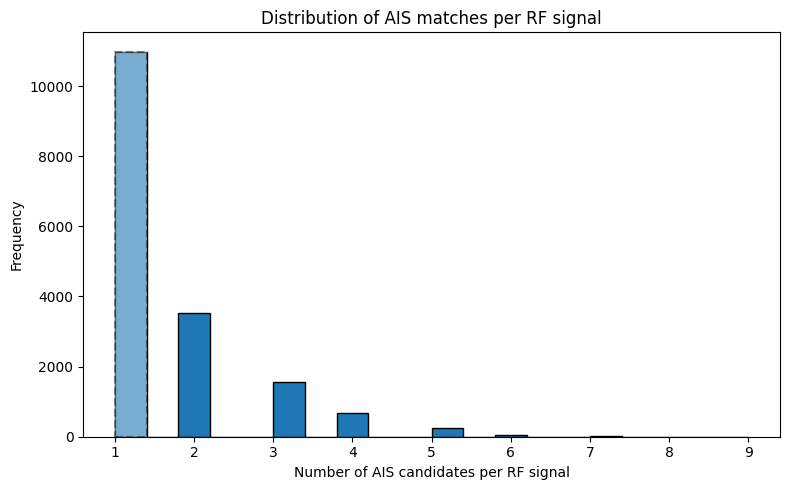

In [2]:
# Load data
df_preselection = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/AIS_RF_preselection_df_time_window_6km.pkl")

df_preselection_multimatch = df_preselection.groupby(['RF_track_id','RF_signal_id']).filter(lambda x: x['AIS_track_id'].count() > 1)
df_preselection_multimatch = df_preselection_multimatch.reset_index(drop=True)

# Compute counts per RF signal
counts = (
    df_preselection
    .groupby(['RF_track_id', 'RF_signal_id'])
    .size()
    .reset_index(name='count')
)

# Plot histogram
plt.figure(figsize=(8, 5))
n, bins, patches_list = plt.hist(counts['count'], bins=20, edgecolor='black')

# Style the first bar
first_bin_left = bins[0]
first_bin_right = bins[1]
first_bar_height = n[0]

plt.gca().add_patch(
    patches.Rectangle(
        (first_bin_left, 0),
        first_bin_right - first_bin_left,
        first_bar_height,
        linewidth=1.5,
        edgecolor='black',
        linestyle='--',
        facecolor='white',
        alpha=0.4
    )
)

# Set x-ticks to even integers only
x_min = int(np.floor(bins[0]))
x_max = int(np.ceil(bins[-1]))
even_ticks = [x for x in range(x_min, x_max + 1)]
plt.xticks(even_ticks)

# Labels and title
plt.xlabel('Number of AIS candidates per RF signal')
plt.ylabel('Frequency')
plt.title('Distribution of AIS matches per RF signal')
plt.tight_layout()
plt.show()


In [3]:
# To get below results -> PHMM needs to be runned
df_forward_results = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/forward_scores_new_preselection_df.pkl")
df_forward_results = df_preselection_multimatch.merge(
df_forward_results,    
    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
df_forward_results
df_forward_results.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(205717000, 82)","(477706700, 4)",False,-29.461525,-0.043010,-0.082629,False
2,1,"(209087000, 10)","(209087000, 10)",True,-29.016735,-0.032313,-0.063782,True
3,1,"(209087000, 10)","(311008600, 17)",False,-33.164059,-0.070412,-0.130301,False
4,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False


In [4]:
# Calculate the average number of AIS tracks linked to each RF track 
AIS_tracks_per_RF_signal = df_forward_results.groupby(["RF_signal_id", "RF_track_id"])["AIS_track_id"].nunique()
average_AIS_matches_per_RF_signal = AIS_tracks_per_RF_signal.mean()
print(f"Average number of AIS tracks per RF track: {average_AIS_matches_per_RF_signal:.2f}")

Average number of AIS tracks per RF track: 2.65


In [66]:
def get_best_alignments(df, score_col):
    idx = df.groupby(['RF_signal_id', 'RF_track_id'])[score_col].idxmax()
    return df.loc[idx].reset_index(drop=True)#[["RF_signal_id", "RF_track_id", "AIS_track_id", "is_true_match", score_col]]

In [68]:
df_best_norm = get_best_alignments(df_forward_results, "normalized_forward_score")
df_best_norm.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False
2,1,"(209087000, 15)","(209087000, 15)",True,-21.794717,-0.034108,-0.065073,True
3,1,"(209690000, 12)","(209690000, 12)",True,-51.843000,-0.028438,-0.060253,True
4,1,"(209690000, 25)","(209690000, 25)",True,-49.567685,-0.029452,-0.061905,True


In [69]:
def calculate_precision(df_best):
    TP = df_best["is_true_match"].sum()
    FP = (~df_best["is_true_match"]).sum()
    precision = TP / (TP + FP) 
    return (f"The precision score is: {precision:.4f}")

In [70]:
calculate_precision(df_best_norm)

'The precision score is: 0.6955'

In [71]:
def compute_time_dist_diff(df_best, df_train, suffix=""):
    # Make RF dataframe
    df_RF = df_train[df_train["RF"].notna()].copy()
    df_RF = df_RF[["ID", "RF_Timestamp", "RF"]]
    df_RF["RF_signal_id"] = df_RF.groupby("ID").cumcount() + 1

    # Merge RF with best alignments 
    df_merged = df_best.merge(df_RF.rename({"ID": "RF_track_id"}, axis=1), on=["RF_signal_id", "RF_track_id"], how="left")

    # Make AIS dataframe
    df_AIS = df_train[df_train["AIS"].notna()].copy()
    df_AIS_grouped = df_AIS.groupby("ID")
    
    if suffix != "":
        suffix = f"_{suffix}"

    # Function
    def compute_diffs(row):
        seq = df_AIS_grouped.get_group(row["AIS_track_id"])
        AIS_time, AIS_coords = min(
            zip(seq["AIS_Timestamp"], seq["AIS"]), 
            key=lambda x: abs(x[0] - row["RF_Timestamp"]).total_seconds())
            
        time_diff = abs((row["RF_Timestamp"] - AIS_time).total_seconds())
        distance_diff = haversine(row["RF"], AIS_coords)
            
        return pd.Series({
            f"AIS_Timestamp{suffix}": AIS_time,
            f"AIS{suffix}": AIS_coords,
            f"time_diff{suffix}": time_diff, 
            f"distance_diff{suffix}": distance_diff
            })
        
    cols = [
        f"AIS_Timestamp{suffix}", 
        f"AIS{suffix}", 
        f"time_diff{suffix}", 
        f"distance_diff{suffix}"
    ]
        
    df_merged[cols] = df_merged.apply(compute_diffs, axis=1)
    return df_merged

In [72]:
def boxplot_time_dist_diff(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates boxplots of time_diff and distance_diff for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    time_correct = df_correct['time_diff']
    time_chosen = df_chosen['time_diff']
    dist_correct = df_correct['distance_diff']
    dist_chosen = df_chosen['distance_diff']

    data_time = [time_correct, time_chosen]
    data_dist = [dist_correct, dist_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        time_shouldbe = df_shouldbe['time_diff']
        dist_shouldbe = df_shouldbe['distance_diff']
        data_time.append(time_shouldbe)
        data_dist.append(dist_shouldbe)
        labels.append('Incorrect (should-be)')

    mean_time = [x.mean() for x in data_time]
    med_time = [x.median() for x in data_time]
    mean_dist = [x.mean() for x in data_dist]
    med_dist = [x.median() for x in data_dist]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Time difference boxplot
    ax1.boxplot(data_time, tick_labels=labels, showfliers=False, showmeans=True)
    ax1.set_title('Time difference (without outliers)')
    ax1.set_ylabel('Seconds')
    for i, (mean, median) in enumerate(zip(mean_time, med_time), start=1):
        ax1.text(i + 0.17, mean, f"mean {mean:.1f}", color='green', ha='left', va='center')
        ax1.text(i - 0.17, median, f"median {median:.1f}", color='darkorange', ha='right', va='center')

    # Distance difference boxplot
    ax2.boxplot(data_dist, tick_labels=labels, showfliers=False, showmeans=True)
    ax2.set_title('Distance difference (without outliers)')
    ax2.set_ylabel('Kilometers')
    
    for i, (mean, median) in enumerate(zip(mean_dist, med_dist), start=1):
        ax2.text(i + 0.17, mean, f"mean {mean:.1f}", color='green', ha='left', va='center')
        ax2.text(i - 0.17, median, f"median {median:.1f}", color='darkorange', ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [73]:
def histplot_time_dist_error(df_chosen, df_shouldbe):
    """
    Maakt histogrammen van de fout in tijd en afstand
    tussen incorrect gekozen match en de correcte (should-be).
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["time_error"] = df_merged["time_diff_chosen"] - df_merged["time_diff_shouldbe"]
    df_merged["distance_error"] = df_merged["distance_diff_chosen"] - df_merged["distance_diff_shouldbe"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Time error
    sns.histplot(df_merged["time_error"], bins=50, kde=True, ax=ax1)
    ax1.set_title("Histogram of time error (chosen − should-be)")
    ax1.set_xlabel("Tijd-fout (seconden)")
    ax1.set_ylabel("Frequentie")

    # Distance error
    sns.histplot(df_merged["distance_error"], bins=50, kde=True, ax=ax2)
    ax2.set_title("Histogram of distance error (chosen − should-be)")
    ax2.set_xlabel("Afstand-fout (kilometers)")
    ax2.set_ylabel("Frequentie")

    plt.tight_layout()
    plt.show()

In [74]:
df_AIS = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/AIS_sample_no_RF_5000.pkl") 
df_AIS_stats = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/statistics_sample_5000.pkl")  
df_train_set = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/train_data_sample_5000.pkl") 

In [75]:
correct = df_best_norm[df_best_norm["is_true_match"]]
incorrect = df_best_norm[~df_best_norm["is_true_match"]]

df_correct = compute_time_dist_diff(correct, df_train_set)
df_incorrect_chosen = compute_time_dist_diff(incorrect, df_train_set)
df_incorrect_shouldbe_raw = (
    df_forward_results[df_forward_results["is_true_match"]]
    .merge(df_incorrect_chosen[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner"))
df_incorrect_shouldbe = compute_time_dist_diff(df_incorrect_shouldbe_raw, df_train_set)

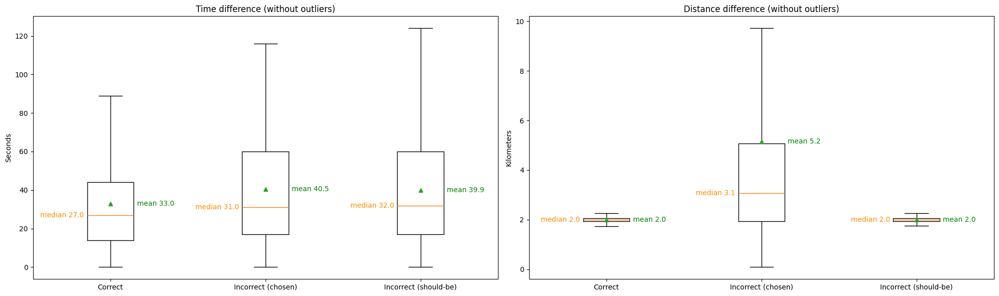

In [76]:
boxplot_time_dist_diff(df_correct, df_incorrect_chosen, df_incorrect_shouldbe)

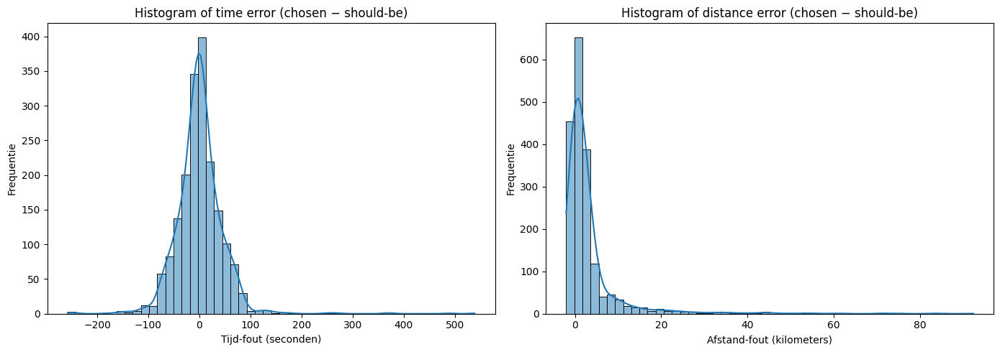

In [77]:
histplot_time_dist_error(df_incorrect_chosen, df_incorrect_shouldbe)

In [78]:
def compute_mean_intra_time(df, df_AIS_stats):
    """
    Adds 'mean_intra_time_diff' column to a dataframe
    """
    return df.merge(df_AIS_stats[["ID", "mean_intra_time_diff"]], left_on = "AIS_track_id", right_on = "ID", how = "left")

In [79]:
def boxplot_mean_intra_time(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of mean_intra_time_diff for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    intra_correct = df_correct['mean_intra_time_diff']
    intra_chosen  = df_chosen['mean_intra_time_diff']

    data = [intra_correct, intra_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        intra_shouldbe = df_shouldbe['mean_intra_time_diff']
        data.append(intra_shouldbe)
        labels.append('Incorrect (should-be)')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
    ax.set_title('Mean intra-time difference: Correct vs Incorrect')
    ax.set_ylabel('Seconds')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "green", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [80]:
def histplot_intra_time_error(df_chosen, df_shouldbe):
    """
    Plots a histogram of the error in mean intra-time between
    incorrectly chosen and should-be AIS tracks.
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["intra_time_error"] = (df_merged["mean_intra_time_diff_chosen"] - df_merged["mean_intra_time_diff_shouldbe"])

    plt.figure(figsize=(8, 6))
    sns.histplot(df_merged["intra_time_error"], bins=50, kde=True)
    plt.title("Histogram of mean intra-time error (chosen − should-be)")
    plt.xlabel("Mean intra-time error (seconds)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [81]:
df_correct_stats = compute_mean_intra_time(df_correct, df_AIS_stats)
df_incorrect_chosen_stats = compute_mean_intra_time(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_mean_intra_time(df_incorrect_shouldbe, df_AIS_stats)

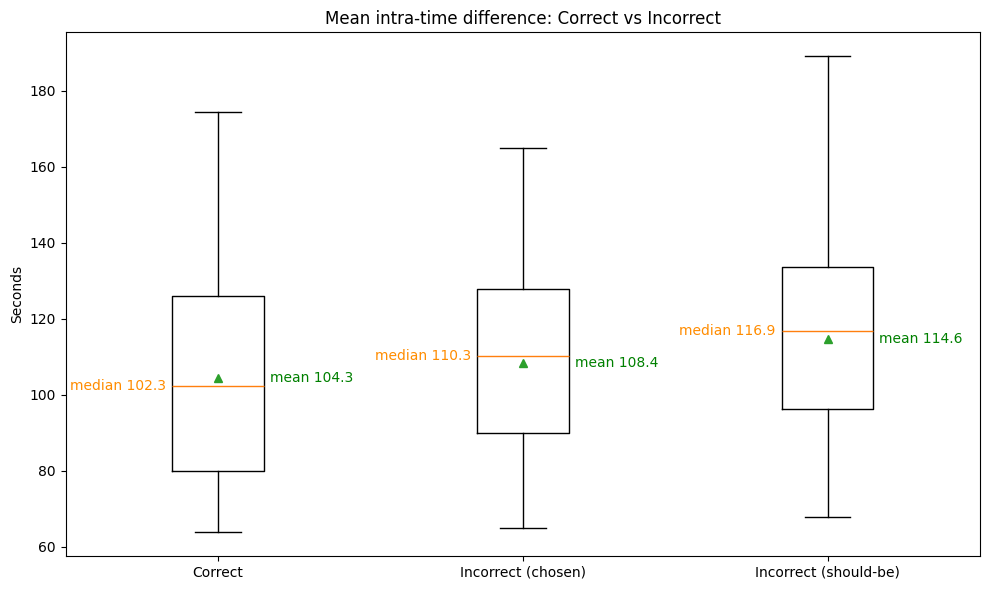

In [82]:
boxplot_mean_intra_time(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

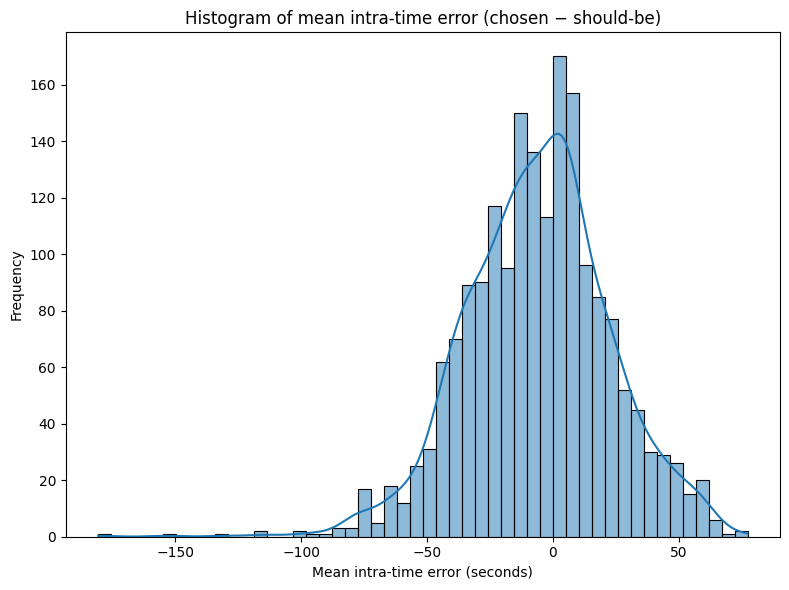

In [83]:
histplot_intra_time_error(df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

In [84]:
def compute_track_behavior(df, df_AIS, stationary_threshold = 5):
    """
    Adds per-track behavior statistics to the given dataframe
    """
    df_AIS = df_AIS.copy()
    df_AIS["is_stationary"] = df_AIS["speed_kph"] < stationary_threshold
    track_behavior_stats = (
        df_AIS
        .groupby("ID")
        .agg(
            std_speed_kph = ("speed_kph", "std"),
            stationary_ratio = ("is_stationary", "mean")
        )
        .reset_index()
        .set_index("ID")
    )
    return df.merge(track_behavior_stats, left_on = "AIS_track_id", right_on = "ID", how = "left")

In [85]:
def boxplot_track_behavior(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates boxplots for track-level behavior metrics:
    - std_speed_kph (speed variability)
    - stationary_ratio (proportion of time under threshold)
    """
    speed_correct = df_correct['std_speed_kph']
    speed_chosen  = df_chosen['std_speed_kph']
    station_correct = df_correct['stationary_ratio']
    station_chosen  = df_chosen['stationary_ratio']

    speed_data = [speed_correct, speed_chosen]
    stationary_data = [station_correct, station_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        speed_shouldbe = df_shouldbe['std_speed_kph']
        station_shouldbe = df_shouldbe['stationary_ratio']
        speed_data.append(speed_shouldbe)
        stationary_data.append(station_shouldbe)
        labels.append('Incorrect (should-be)')

    speed_means = [x.mean() for x in speed_data]
    speed_medians = [x.median() for x in speed_data]
    station_means = [x.mean() for x in stationary_data]
    station_medians = [x.median() for x in stationary_data]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    ax1.boxplot(speed_data, tick_labels=labels, showfliers=False, showmeans=True)
    ax1.set_title("Speed Variation (std_speed_kph)")
    ax1.set_ylabel("Standard Deviation of Speed (km/h)")

    for i, (m, med) in enumerate(zip(speed_means, speed_medians), start=1):
        ax1.text(i + 0.17, m,   f"mean {m:.2f}", color="green", ha='left', va='center')
        ax1.text(i - 0.17, med, f"median {med:.2f}", color="darkorange", ha='right', va='center')

    ax2.boxplot(stationary_data, tick_labels=labels, showfliers=False, showmeans=True)
    ax2.set_title("Stationary Behavior (stationary_ratio)")
    ax2.set_ylabel("Proportion of Time Stationary (< 5 km/h)")

    for i, (m, med) in enumerate(zip(station_means, station_medians), start=1):
        ax2.text(i + 0.17, m,   f"mean {m:.2f}", color="green", ha='left', va='center')
        ax2.text(i - 0.17, med, f"median {med:.2f}", color="darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()


In [86]:
def histplot_track_behavior_errors(df_chosen, df_shouldbe):
    """
    Plots histograms of the errors between incorrectly chosen and should-be AIS tracks
    for:
    - std_speed_kph (speed variability)
    - stationary_ratio (proportion of time under threshold)
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["speed_std_error"] = (df_merged["std_speed_kph_chosen"] - df_merged["std_speed_kph_shouldbe"])
    df_merged["stationary_error"] = (df_merged["stationary_ratio_chosen"] - df_merged["stationary_ratio_shouldbe"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df_merged["speed_std_error"], bins=50, kde=True, ax=axes[0])
    axes[0].set_title("Speed std error (chosen − should-be)")
    axes[0].set_xlabel("Speed std error (km/h)")
    axes[0].set_ylabel("Frequency")

    sns.histplot(df_merged["stationary_error"], bins=50, kde=True, ax=axes[1])
    axes[1].set_title("Stationary ratio error (chosen − should-be)")
    axes[1].set_xlabel("Stationary ratio error")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


In [87]:
df_correct_behavior = compute_track_behavior(df_correct, df_AIS)
df_incorrect_chosen_behavior = compute_track_behavior(df_incorrect_chosen, df_AIS)
df_incorrect_shouldbe_behavior = compute_track_behavior(df_incorrect_shouldbe, df_AIS)

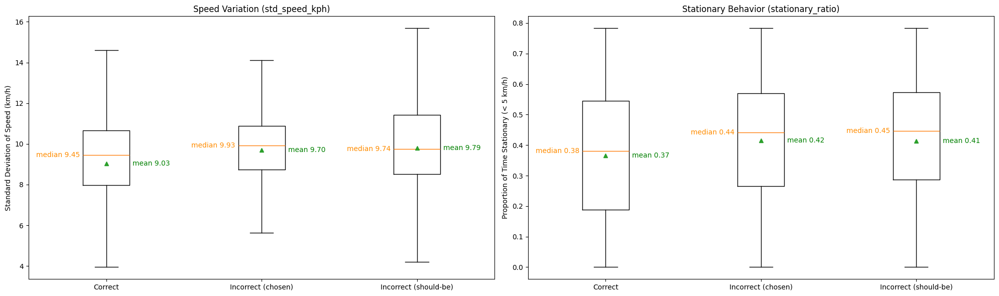

In [88]:
boxplot_track_behavior(df_correct_behavior, df_incorrect_chosen_behavior, df_incorrect_shouldbe_behavior)

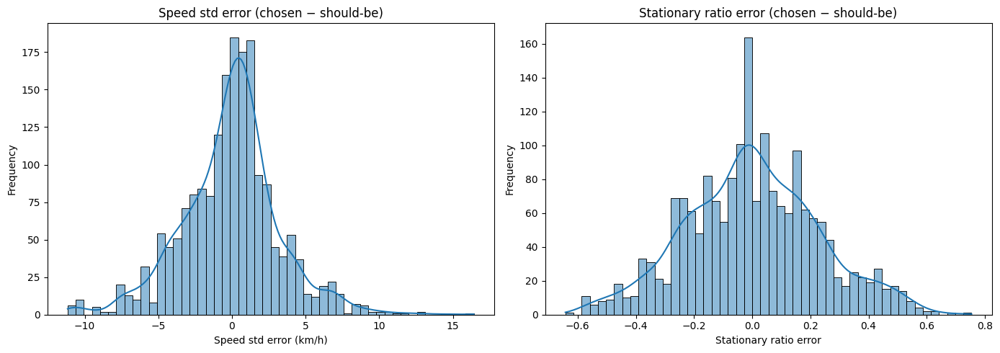

In [89]:
histplot_track_behavior_errors(df_incorrect_chosen_behavior, df_incorrect_shouldbe_behavior)

In [90]:
def compute_track_length(df, df_AIS_stats):
    """
    Adds 'mean_intra_time_diff' column to a dataframe
    """
    return df.merge(df_AIS_stats[["ID", "#points"]], left_on = "AIS_track_id", right_on = "ID", how = "left")

In [91]:
def boxplot_track_length(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of track_length for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    length_correct = df_correct['#points']
    length_chosen  = df_chosen['#points']

    data = [length_correct, length_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        length_shouldbe = df_shouldbe['#points']
        data.append(length_shouldbe)
        labels.append('Incorrect (should-be)')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
    ax.set_title('Number of AIS points per track: Correct vs Incorrect')
    ax.set_ylabel('Number of points')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "green", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [92]:
df_correct_tracks = compute_track_length(df_correct, df_AIS_stats)
df_incorrect_chosen_tracks = compute_track_length(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_tracks = compute_track_length(df_incorrect_shouldbe, df_AIS_stats)

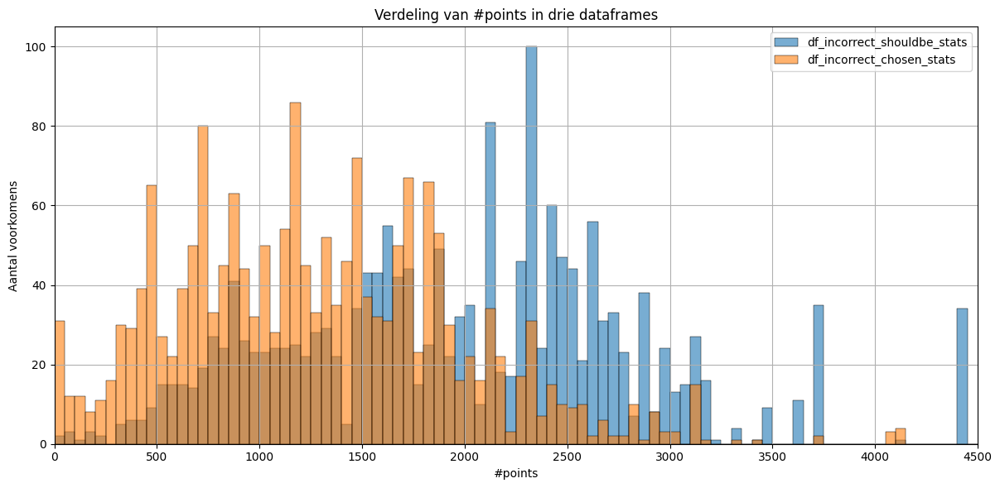

In [93]:
bins = range(0, 9100, 50) 

plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_chosen_tracks['#points'], bins=bins, alpha=0.6, label='df_incorrect_shouldbe_stats')
sns.histplot(df_incorrect_shouldbe_tracks['#points'], bins=bins, alpha=0.6, label='df_incorrect_chosen_stats')

plt.xlabel('#points')
plt.ylabel('Aantal voorkomens')
plt.title('Verdeling van #points in drie dataframes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()


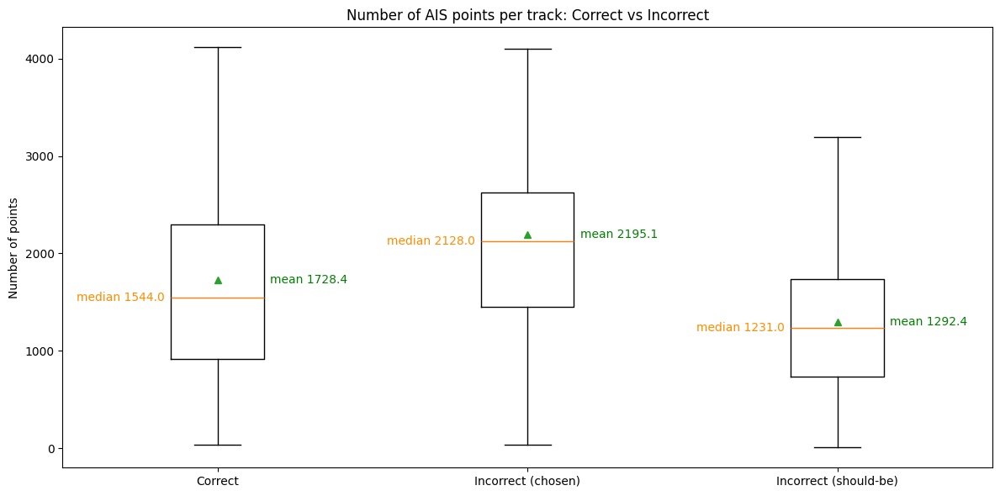

In [94]:
boxplot_track_length(df_correct_tracks, df_incorrect_chosen_tracks, df_incorrect_shouldbe_tracks)

In [95]:
df_best_norm_alpha = get_best_alignments(df_forward_results, "normalized_forward_score_alpha")
df_best_norm_alpha.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False
2,1,"(209087000, 15)","(209087000, 15)",True,-21.794717,-0.034108,-0.065073,True
3,1,"(209690000, 12)","(209690000, 12)",True,-51.843000,-0.028438,-0.060253,True
4,1,"(209690000, 25)","(209690000, 25)",True,-49.567685,-0.029452,-0.061905,True


In [96]:
calculate_precision(df_best_norm_alpha)

'The precision score is: 0.7782'

In [97]:
correct_alpha = df_best_norm_alpha[df_best_norm_alpha["is_true_match"]]
incorrect_alpha = df_best_norm_alpha[~df_best_norm_alpha["is_true_match"]]

df_correct_alpha = compute_time_dist_diff(correct_alpha, df_train_set)
df_incorrect_chosen_alpha = compute_time_dist_diff(incorrect_alpha, df_train_set)
df_incorrect_shouldbe_raw_alpha = (
    df_forward_results[df_forward_results["is_true_match"]]
    .merge(df_incorrect_chosen_alpha[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner"))
df_incorrect_shouldbe_alpha = compute_time_dist_diff(df_incorrect_shouldbe_raw_alpha, df_train_set)

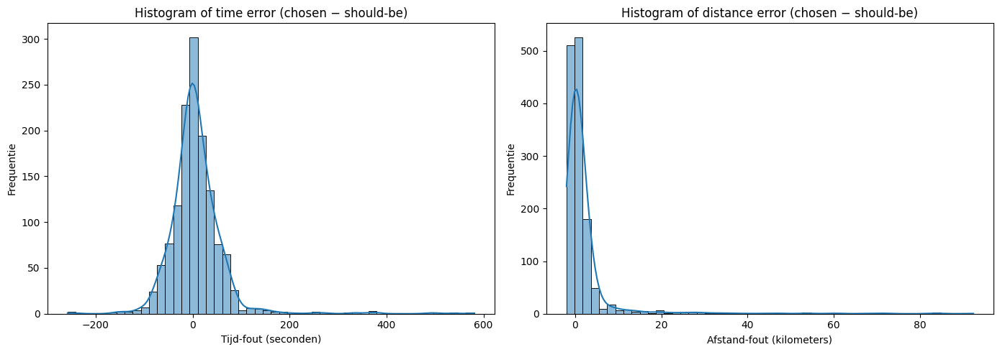

In [98]:
histplot_time_dist_error(df_incorrect_chosen_alpha, df_incorrect_shouldbe_alpha)

In [42]:
df_incorrect_chosen.tail(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff
1851,24,"(256524000, 97)","(636022464, 30)",False,-67.385209,-0.027868,-0.060737,False,2024-01-26 15:27:16,"[38.96300949474396, -76.41017314589891]",2024-01-26 15:26:50,"[38.96507, -76.40624]",26.0,0.410039
1852,25,"(636022464, 30)","(256524000, 97)",False,-70.457358,-0.028037,-0.061341,False,2024-01-26 19:11:03,"[38.966686863335006, -76.38115888996596]",2024-01-26 19:09:07,"[38.94884, -76.42029]",116.0,3.922552
1853,31,"(636093060, 4)","(368270390, 0)",False,-120.757782,-0.027271,-0.063143,False,2024-01-05 19:11:03,"[29.355030400437105, -94.79470224495785]",2024-01-05 19:11:38,"[29.31437, -94.79617]",35.0,4.523475
1854,32,"(316052496, 0)","(366938770, 0)",False,-147.864428,-0.026666,-0.063147,False,2024-01-05 11:40:10,"[42.299554425448065, -83.06295458284362]",2024-01-05 11:38:24,"[42.30172, -83.08968]",106.0,2.211117
1855,41,"(366904880, 0)","(367121010, 0)",False,-187.504843,-0.026570,-0.064455,False,2024-01-06 19:11:03,"[46.74284326350594, -92.1033090578235]",2024-01-06 19:10:54,"[46.76971, -92.06244]",9.0,4.314877


In [35]:
df_AIS_stats[df_AIS_stats["ID"]== (636016975, 100)]["#points"], df_AIS_stats[df_AIS_stats["ID"]== (210210000, 19)]["#points"]

(14656    1205
 Name: #points, dtype: int64,
 195    47
 Name: #points, dtype: int64)

In [31]:
AIS_filtered = df_AIS[df_AIS["ID"].isin([(636016975, 100), (210210000, 19)])]
RF_filtered = df_train_set[(df_train_set["ID"]== (210210000, 19)) & (~df_train_set["RF"].isna())].iloc[0]

In [32]:
# Initialize the interactive map
map_center = [AIS_filtered["LAT"].mean(), AIS_filtered["LON"].mean()]
map = folium.Map(location=map_center, zoom_start=7, tiles="CartoDB Positron")

# Kleuren per SubTrackID
unique_ids = AIS_filtered["track_id"].unique()
colors = ["#e14a5b", "#117b88", "#9dc6ce", "#f46d43", "#fee08b"]
color_map = {track_id: colors[i % len(colors)] for i, track_id in enumerate(unique_ids)}

# Plot AIS route
ais_layer = folium.FeatureGroup(name="AIS Tracks")
for (mmsi, track_id), group in AIS_filtered.groupby("ID"):
    color = color_map[track_id]
    for _, row in group.iterrows():
        heading = 315 + row['Heading']
        icon_html = f'''
            <div style="font-size:12px; transform: rotate({heading}deg);">
                <i class="fa-solid fa-location-arrow" style="color: {color};"></i>
            </div>
            '''
        folium.Marker(
            location=(row['LAT'], row['LON']),
            tooltip=f"AIS Point\nMMSI: {mmsi}\nTrack: {track_id}\nTime: {row['BaseDateTime']}",
            icon=folium.DivIcon(html=icon_html)
        ).add_to(ais_layer)
ais_layer.add_to(map)

# Plot RF signals
rf_layer = folium.FeatureGroup(name="RF Signals")
track_id = RF_filtered["track_id"]
color = "blue"
icon_html = f'''
    <i class="fa-solid fa-star" style="color: {color};"></i>
    '''
folium.Marker(
    location=RF_filtered["RF"],
    tooltip=f"RF signal: {RF_filtered['RF_Timestamp']}",
    icon=folium.DivIcon(html=icon_html),
).add_to(rf_layer)
rf_layer.add_to(map)

folium.LayerControl(collapsed=False).add_to(map)
map

In [40]:
AIS_filtered = df_AIS[df_AIS["ID"].isin([(351567000, 19), (209087000, 10)])]
RF_filtered = df_train_set[(df_train_set["ID"]== (209087000, 10)) & (~df_train_set["RF"].isna())].iloc[0]

In [41]:
# Initialize the interactive map
map_center = [AIS_filtered["LAT"].mean(), AIS_filtered["LON"].mean()]
map = folium.Map(location=map_center, zoom_start=7, tiles="CartoDB Positron")

# Kleuren per SubTrackID
unique_ids = AIS_filtered["track_id"].unique()
colors = ["#e14a5b", "#117b88", "#9dc6ce", "#f46d43", "#fee08b"]
color_map = {track_id: colors[i % len(colors)] for i, track_id in enumerate(unique_ids)}

# Plot AIS route
ais_layer = folium.FeatureGroup(name="AIS Tracks")
for (mmsi, track_id), group in AIS_filtered.groupby("ID"):
    color = color_map[track_id]
    for _, row in group.iterrows():
        heading = 315 + row['Heading']
        icon_html = f'''
            <div style="font-size:12px; transform: rotate({heading}deg);">
                <i class="fa-solid fa-location-arrow" style="color: {color};"></i>
            </div>
            '''
        folium.Marker(
            location=(row['LAT'], row['LON']),
            tooltip=f"AIS Point\nMMSI: {mmsi}\nTrack: {track_id}\nTime: {row['BaseDateTime']}",
            icon=folium.DivIcon(html=icon_html)
        ).add_to(ais_layer)
ais_layer.add_to(map)

# Plot RF signals
rf_layer = folium.FeatureGroup(name="RF Signals")
track_id = RF_filtered["track_id"]
color = "blue"
icon_html = f'''
    <i class="fa-solid fa-star" style="color: {color};"></i>
    '''
folium.Marker(
    location=RF_filtered["RF"],
    tooltip=f"RF signal: {RF_filtered['RF_Timestamp']}",
    icon=folium.DivIcon(html=icon_html),
).add_to(rf_layer)
rf_layer.add_to(map)

folium.LayerControl(collapsed=False).add_to(map)
map

In [43]:
AIS_filtered = df_AIS[df_AIS["ID"].isin([(368270390, 0), (636093060, 4)])]
RF_filtered = df_train_set[(df_train_set["ID"]== (636093060, 4)) & (~df_train_set["RF"].isna())].iloc[0]

In [44]:
# Initialize the interactive map
map_center = [AIS_filtered["LAT"].mean(), AIS_filtered["LON"].mean()]
map = folium.Map(location=map_center, zoom_start=7, tiles="CartoDB Positron")

# Kleuren per SubTrackID
unique_ids = AIS_filtered["track_id"].unique()
colors = ["#e14a5b", "#117b88", "#9dc6ce", "#f46d43", "#fee08b"]
color_map = {track_id: colors[i % len(colors)] for i, track_id in enumerate(unique_ids)}

# Plot AIS route
ais_layer = folium.FeatureGroup(name="AIS Tracks")
for (mmsi, track_id), group in AIS_filtered.groupby("ID"):
    color = color_map[track_id]
    for _, row in group.iterrows():
        heading = 315 + row['Heading']
        icon_html = f'''
            <div style="font-size:12px; transform: rotate({heading}deg);">
                <i class="fa-solid fa-location-arrow" style="color: {color};"></i>
            </div>
            '''
        folium.Marker(
            location=(row['LAT'], row['LON']),
            tooltip=f"AIS Point\nMMSI: {mmsi}\nTrack: {track_id}\nTime: {row['BaseDateTime']}",
            icon=folium.DivIcon(html=icon_html)
        ).add_to(ais_layer)
ais_layer.add_to(map)

# Plot RF signals
rf_layer = folium.FeatureGroup(name="RF Signals")
track_id = RF_filtered["track_id"]
color = "blue"
icon_html = f'''
    <i class="fa-solid fa-star" style="color: {color};"></i>
    '''
folium.Marker(
    location=RF_filtered["RF"],
    tooltip=f"RF signal: {RF_filtered['RF_Timestamp']}",
    icon=folium.DivIcon(html=icon_html),
).add_to(rf_layer)
rf_layer.add_to(map)

folium.LayerControl(collapsed=False).add_to(map)
map

In [46]:
# stats verkeerd gekozen track 
df_AIS_stats[df_AIS_stats["ID"] == (368270390, 0)]

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,density_score,sampling_weight
8501,"(368270390, 0)",4428,8399.916667,5.248442,0.25638,0.58207,113.845719,11.079528,15.956749


In [47]:
# stats track die hij eigenlijk had moeten kiezen  
df_AIS_stats[df_AIS_stats["ID"] == (636093060, 4)]

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,density_score,sampling_weight
16510,"(636093060, 4)",2967,7274.833333,7.325028,1.48236,0.76772,147.164531,11.060041,15.879202


In [99]:
# stats verkeerd gekozen track 
df_AIS_stats[df_AIS_stats["ID"] == (351567000, 19)]

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,density_score,sampling_weight
5195,"(351567000, 19)",1074,2018.533333,12.515512,1.60066,2.24634,112.872321,8.337581,8.039729


In [100]:
# stats track die hij eigenlijk had moeten kiezen  
df_AIS_stats[df_AIS_stats["ID"] == (209087000, 10)]

,ID,#points,track_duration,avg_speed_kph,lat_span,lon_span,mean_intra_time_diff,density_score,sampling_weight
28,"(209087000, 10)",898,2013.883333,11.256221,1.03456,1.40109,134.707915,7.481268,6.490353


In [ ]:
AIS_filtered = df_AIS[df_AIS["ID"].isin([(351567000, 19), (209087000, 10)])]
RF_filtered = df_train_set[(df_train_set["ID"]== (209087000, 10)) & (~df_train_set["RF"].isna())].iloc[0]